<a href="https://colab.research.google.com/github/Shreyas0105/ML-Lab/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

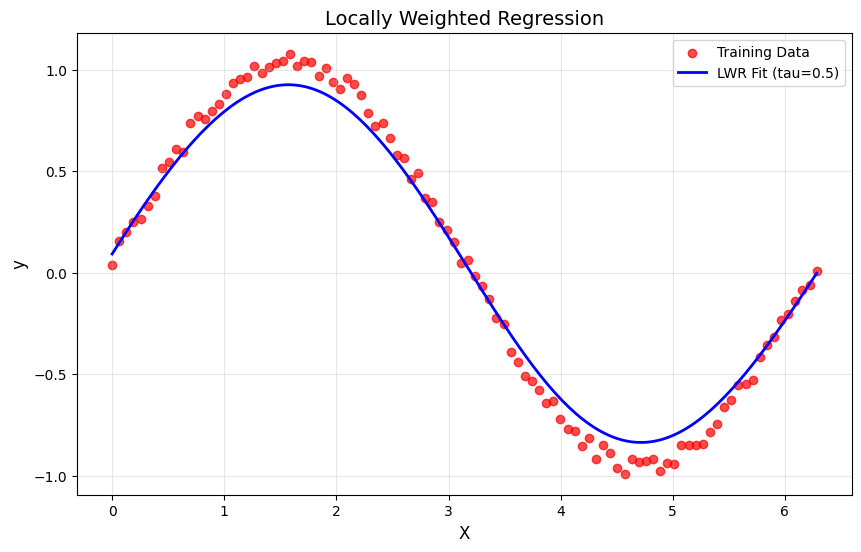

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    X_transpose_W = X.T @ W
    theta = np.linalg.inv(X_transpose_W @ X) @ X_transpose_W @ y
    return x @ theta
np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.random(100)
X_bias = np.c_[np.ones(X.shape), X]
X_test = np.linspace(0, 2 * np.pi, 200)
X_test_bias = np.c_[np.ones(X_test.shape), X_test]
tau = 0.5
y_pred = np.array([locally_weighted_regression(xi, X_bias, y, tau) for xi in X_test_bias])
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Training Data', alpha=0.7)
plt.plot(X_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Locally Weighted Regression', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()


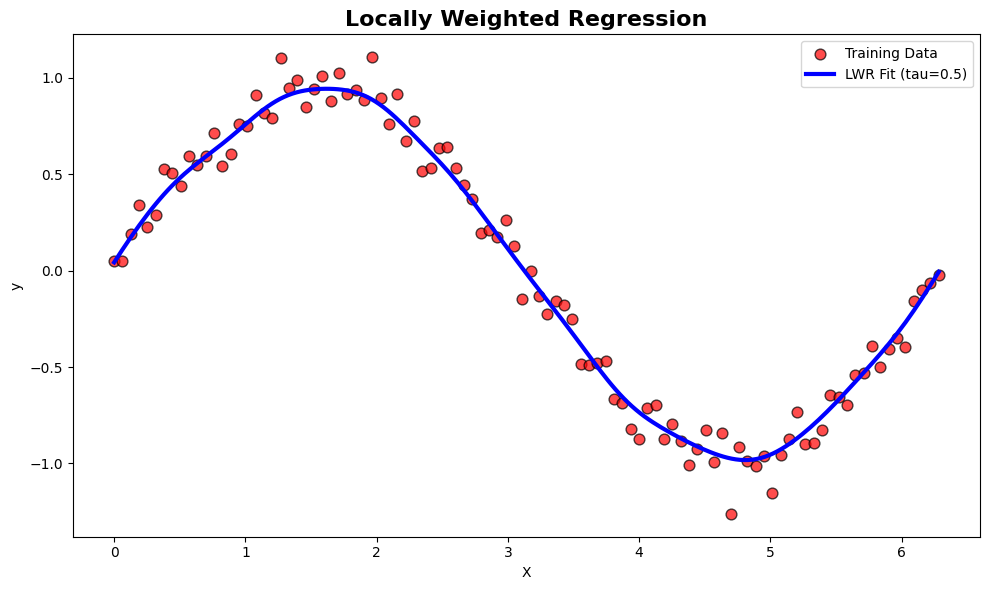

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
np.random.seed(42)
X=np.linspace(0,2*np.pi,100)
y=np.sin(X)+0.1*np.random.randn(100)
model=KernelReg(y,X,'c')
x_test=np.linspace(0,2*np.pi,200); y_pred,_=model.fit(x_test)
plt.figure(figsize=(10,6))
plt.scatter(X,y,color='red',edgecolor='black',s=60,alpha=0.7,label="Training Data")
plt.plot(x_test,y_pred,color='blue',linewidth=3,label="LWR Fit (tau=0.5)")
plt.title("Locally Weighted Regression",fontsize=16,fontweight='bold')
plt.xlabel("X"); plt.ylabel("y")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
